In [ ]:
import pickle
from pathlib import Path
import pandas as pd
import logging
from syllabification import get_largest_ipa_corpus
from helpers import load_config

# ----- Get number of words and sentences for each dataset -----

import os
import pandas as pd
import logging
import pickle
from pathlib import Path
from helpers import load_config
from syllabification import get_largest_ipa_corpus

processing_types = ['phones', 'sylls', 'words']
text_types = ['within_words', 'across_sentences']
n_values = [1, 2, 3, 4]
folder_name = "produced_data_large_corpus"
corpus_size = 'max'

def get_dataset_size(language, processing_types):
    folder = Path(folder_name) / language
    config_dict = load_config(language)

    if corpus_size != 'max':
        raise ValueError("Only 'max' corpus_size supported in this version")

    largest_corpus_size = config_dict['Corpus Size']
    exists, is_near_expected, ipa_corpus = get_largest_ipa_corpus(language, largest_corpus_size, folder)

    if not exists or not is_near_expected:
        logging.warning(f"❌ No IPA corpus available for {language}. Skipping...")
        return None

    if ipa_corpus:
        size = int(ipa_corpus.stem.split("_size:")[-1])
        print(f"📄 Found data for {language}: {ipa_corpus}")
    else:
        raise FileNotFoundError("get_largest_ipa_corpus() did not return expected IPA corpus path")

    results = {"language": language}

    for processing_type in processing_types:
        # Determine file path
        if processing_type == 'words':
            file_path = ipa_corpus
        else:
            subfolder = folder / processing_type
            filename = f"{'syllabified' if processing_type == 'sylls' else 'phonized'}_{language}_size:{size}.pkl"
            file_path = subfolder / filename

        # Load the data
        try:
            with open(file_path, "rb") as f:
                tokenized_data = pickle.load(f)
        except Exception as e:
            logging.error(f"❌ Failed to load {processing_type} corpus for {language}: {e}")
            continue

        num_sentences = len(tokenized_data)

        if processing_type == 'words':
            num_units = sum(len(sentence) for sentence in tokenized_data)
        else:  # sylls or phones
            num_units = sum(len(word) for sentence in tokenized_data for word in sentence)

        key = f"num_{processing_type}"
        results[key] = num_units
        results["num_sentences"] = num_sentences  # Only once — same for all

        print(f"🧮 Language: {language} | Sentences: {num_sentences:,} | {processing_type.title()}: {num_units:,}")

    return results if len(results) > 1 else None



# Run for one or more languages
languages = ['FRA', 'DEU', 'ENG']  # or ['FRA', 'ENG', 'DEU'] 
processing_types = ['phones', 'sylls']

# --- Step 1: Load input CSV ---
input_csv = Path(folder_name) / "statistics_summary.csv"
df = pd.read_csv(input_csv)

# --- Step 2: Get unique languages ---
languages = df["language"].unique()

# --- Step 3: Compute sizes per language ---
sizes = []
for lang in languages:
    result = get_dataset_size(lang, processing_types)
    if result:
        sizes.append(result)

sizes_df = pd.DataFrame(sizes)

# --- Step 4: Merge sizes back into original DataFrame ---
df_merged = df.merge(sizes_df, on="language", how="left")

# --- Step 5: Save updated CSV ---
df_merged.to_csv(input_csv, index=False)
print(f"✅ Saved to {input_csv}")

📄 Found data for DEU: produced_data_large_corpus/DEU/ipa_corpus_DEU_size:642765.pkl
🧮 Language: DEU | Sentences: 642,765 | Phones: 21,711,273
🧮 Language: DEU | Sentences: 642,765 | Sylls: 7,891,134
📄 Found data for ENG: produced_data_large_corpus/ENG/ipa_corpus_ENG_size:450000.pkl
🧮 Language: ENG | Sentences: 450,000 | Phones: 12,899,039
🧮 Language: ENG | Sentences: 450,000 | Sylls: 4,818,106
📄 Found data for FRA: produced_data_large_corpus/FRA/ipa_corpus_FRA_size:570587.pkl
🧮 Language: FRA | Sentences: 570,587 | Phones: 13,229,820
🧮 Language: FRA | Sentences: 570,587 | Sylls: 5,965,656
✅ Saved to produced_data_large_corpus/statistics_summary.csv


In [ ]:
from joblib import Parallel, delayed
import pickle
from pathlib import Path
import pandas as pd
import logging
from collections import Counter
from markov_models import MarkovModel
from syllabification import get_largest_ipa_corpus
from helpers import load_config

languages = ['DEU', 'ENG', 'FRA']  # 'ENG', 'FRA', 'DEU'
processing_types = ['phones', 'sylls', 'words']
text_types = ['within_words', 'across_sentences']
n_values = [1, 2, 3, 4]
folder_name = "produced_data_large_corpus"
corpus_size = 'max'  # 'max' or int

loaded_data_cache = {}
loaded_model_cache = {}

def load_pickle_cached(path):
    path = str(path)  # for consistent dict keys
    if path not in loaded_data_cache:
        with open(path, "rb") as f:
            loaded_data_cache[path] = pickle.load(f)
    return loaded_data_cache[path]

def load_model_cached(path):
    path = str(path)
    if path not in loaded_model_cache:
        loaded_model_cache[path] = MarkovModel.load(path)
    return loaded_model_cache[path]


def get_stats_for_all_n(language, processing_type, text_type, n_values):
    folder = Path(folder_name) / language
    config_dict = load_config(language)

    if corpus_size == 'max':
        largest_corpus_size = config_dict['Corpus Size']
        exists, _, existing_path = get_largest_ipa_corpus(language, largest_corpus_size, folder)
        if not exists or existing_path is None:
            logging.warning(f"❌ No IPA corpus available for {language}. Skipping...")
            return None
    else:
        raise ValueError("Only 'max' corpus_size supported in this version")

    existing_corpus_size = int(existing_path.stem.split("_size:")[-1])
    
    if processing_type == 'phones':
        data_path = folder / "phones" / f"phonized_{language}_size:{existing_corpus_size}.pkl"
    elif processing_type == 'sylls':
        data_path = folder / "sylls" / f"syllabified_{language}_size:{existing_corpus_size}.pkl"
    elif processing_type == 'words': 
        data_path = existing_path
    else:
        return None

    if not data_path.exists():
        logging.warning(f"Data for {language} not found at {data_path}. Skipping...")
        return None

    try:
        data = load_pickle_cached(data_path)
    except Exception as e:
        logging.error(f"Error loading {data_path}: {e}")
        return None

    units = [unit for sentence in data for word in sentence for unit in word]
    unit_counts = Counter(units)

    # ⬇ Loop over all n-values here and collect stats
    result_list = []

    for n in n_values:
        model_path = folder / processing_type / f"{language}_{text_type}_markov_model_{n}gram.pkl"
        if not model_path.exists():
            logging.warning(f"Model for {language}, {processing_type}, {text_type}, n={n} not found at {model_path}. Skipping...")
            continue

        try:
            model = load_model_cached(model_path)
        except Exception as e:
            logging.error(f"Error loading model from {model_path}: {e}")
            continue

        result_list.append({
            "language": language,
            "processing_type": processing_type,
            "text_type": text_type,
            "n": n,
            "total_num_units": len(units),
            "total_ngrams": sum(model.ngram_counts.values()),
            "unique_ngrams": len(model.ngram_counts),
            "unique_prefixes": model.total_prefixes,
            "unique_units": len(unit_counts)
        })

    return result_list


from itertools import product

# Group tasks by language, processing_type, text_type (no longer include `n` here)
tasks = list(product(languages, processing_types, text_types))

# Run in parallel
results = Parallel(n_jobs=15, verbose=10)(
    delayed(get_stats_for_all_n)(lang, proc, txt_type, n_values)
    for lang, proc, txt_type in tasks
)

# Flatten the nested result lists (if each call returns a list of dicts)
flat_results = [item for sublist in results if sublist is not None for item in sublist]

df = pd.DataFrame(flat_results)
df.to_csv("produced_data_large_corpus/statistics_summary.csv", index=False)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of  18 | elapsed:    7.0s remaining:   35.0s
[Parallel(n_jobs=15)]: Done   5 out of  18 | elapsed:    7.1s remaining:   18.5s
[Parallel(n_jobs=15)]: Done   7 out of  18 | elapsed:   20.5s remaining:   32.2s
[Parallel(n_jobs=15)]: Done   9 out of  18 | elapsed:   22.5s remaining:   22.5s
[Parallel(n_jobs=15)]: Done  11 out of  18 | elapsed:   25.9s remaining:   16.5s
[Parallel(n_jobs=15)]: Done  13 out of  18 | elapsed:  1.5min remaining:   33.9s
[Parallel(n_jobs=15)]: Done  15 out of  18 | elapsed: 14.6min remaining:  2.9min
[Parallel(n_jobs=15)]: Done  18 out of  18 | elapsed: 173.2min finished


In [6]:
import os 
import pandas as pd
folder_name = "produced_data_large_corpus"
summary_df_path = os.path.join(folder_name, 'statistics_summary.csv')
df = pd.read_csv(summary_df_path)
#print(summary_df.head())

In [7]:
# --- SPLIT INTO SEMANTIC SUBSETS ---
from IPython.display import display

# By n-gram order
df_1gram = df[df["n"] == 1]
df_2gram = df[df["n"] == 2]
df_3gram = df[df["n"] == 3]
df_4gram = df[df["n"] == 4]

# By processing type
df_phones = df[df["processing_type"] == "phones"]
df_sylls = df[df["processing_type"] == "sylls"]

# By text granularity
df_words = df[df["text_type"] == "words"]
df_sentences = df[df["text_type"] == "sentences"]

subset = ["total_ngrams", "unique_ngrams", "unique_prefixes", "unique_units"]

for language in df["language"].unique():
    df_language = df[df["language"] == language]
    styled = df_language.style.set_caption(f"Summary for {language}")\
        .format(precision=0)\
        .bar(subset, color='lightblue')\
        .set_properties(subset, **{'color': 'white'})
    display(styled)

,language,processing_type,text_type,n,total_num_units,total_ngrams,unique_ngrams,unique_prefixes,unique_units
0,DEU,phones,within_words,1,21711273,21711273,69,1,69
1,DEU,phones,within_words,2,21711273,16860540,1806,68,69
2,DEU,phones,within_words,3,21711273,12010968,20116,1770,69
3,DEU,phones,within_words,4,21711273,7917948,86829,19445,69
4,DEU,phones,across_sentences,1,21711273,21711273,69,1,69
5,DEU,phones,across_sentences,2,21711273,21068509,2017,69,69
6,DEU,phones,across_sentences,3,21711273,20425779,27744,2014,69
7,DEU,phones,across_sentences,4,21711273,19783189,200021,27686,69
8,DEU,sylls,within_words,1,7891134,7891134,12480,1,12480
9,DEU,sylls,within_words,2,7891134,3040401,100010,7802,12480


,language,processing_type,text_type,n,total_num_units,total_ngrams,unique_ngrams,unique_prefixes,unique_units
15,ENG,phones,within_words,1,12899039,12899039,69,1,69
16,ENG,phones,within_words,2,12899039,9419146,1378,66,69
17,ENG,phones,within_words,3,12899039,5964328,13768,1340,69
18,ENG,phones,within_words,4,12899039,3639570,46492,12971,69
19,ENG,phones,across_sentences,1,12899039,12899039,69,1,69
20,ENG,phones,across_sentences,2,12899039,12449039,1575,67,69
21,ENG,phones,across_sentences,3,12899039,11999054,25072,1557,69
22,ENG,phones,across_sentences,4,12899039,11549179,199056,24996,69
23,ENG,sylls,within_words,1,4818106,4818106,11392,1,11392
24,ENG,sylls,within_words,2,4818106,1338213,45425,4398,11392


,language,processing_type,text_type,n,total_num_units,total_ngrams,unique_ngrams,unique_prefixes,unique_units
30,FRA,phones,within_words,1,13229820,13229820,63,1,63
31,FRA,phones,within_words,2,13229820,9103192,1649,63,63
32,FRA,phones,within_words,3,13229820,5359122,13436,1578,63
33,FRA,phones,within_words,4,13229820,3281441,42206,11850,63
34,FRA,phones,across_sentences,1,13229820,13229820,63,1,63
35,FRA,phones,across_sentences,2,13229820,12659245,2085,63,63
36,FRA,phones,across_sentences,3,13229820,12088832,30021,2082,63
37,FRA,phones,across_sentences,4,13229820,11518684,237067,29854,63
38,FRA,sylls,within_words,1,5965656,5965656,7800,1,7800
39,FRA,sylls,within_words,2,5965656,1839028,41588,3659,7800


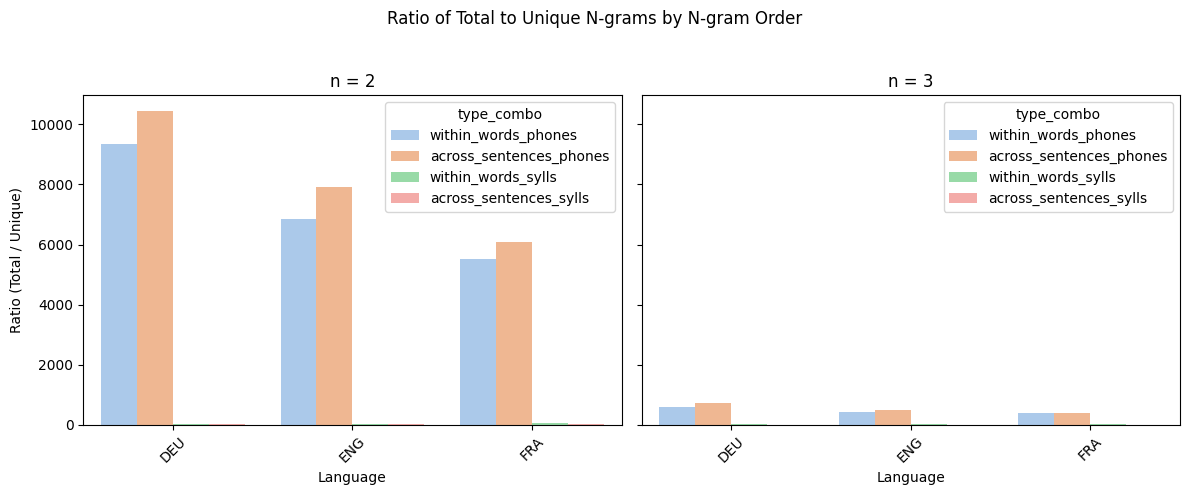

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_ngram_ratios_multi_n(n_values=[2, 3]):
    """
    Three subplots side-by-side, where each subplot corresponds to one n-gram order (n),
    showing the ratio of total to unique n-grams across languages and processing/text types.
    """
    combo_keys = ["text_type", "processing_type"]

    fig, axes = plt.subplots(1, len(n_values), figsize=(6 * len(n_values), 5), sharey=True)

    for ax, n in zip(axes, n_values):
        df_n = df[df["n"] == n].copy()

        # Create combo key for hue
        df_n["type_combo"] = df_n[combo_keys].astype(str).agg("_".join, axis=1)

        # Calculate ratio
        df_n["ratio_total_to_unique"] = df_n["total_ngrams"] / df_n["unique_ngrams"]

        # Plot
        sns.barplot(
            data=df_n,
            x="language",
            y="ratio_total_to_unique",
            hue="type_combo",
            estimator=np.mean,
            errorbar=None,
            palette="pastel",
            ax=ax
        )

        ax.set_title(f"n = {n}")
        ax.set_xlabel("Language")
        ax.set_ylabel("Ratio (Total / Unique)" if ax == axes[0] else "")
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle("Ratio of Total to Unique N-grams by N-gram Order")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Run the function
plot_ngram_ratios_multi_n()



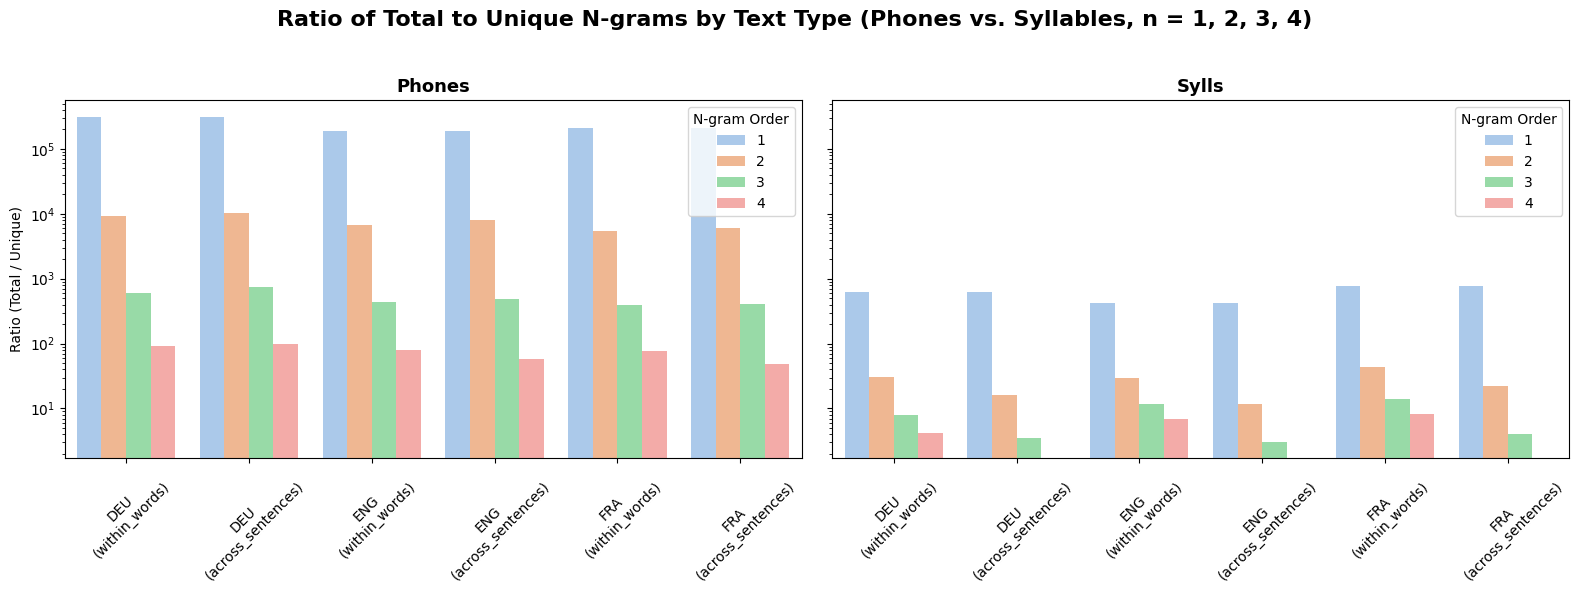

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_phones_vs_sylls_by_texttype_across_n(n_values=[1, 2, 3, 4]):
    """
    Two subplots:
    - Left: phones
    - Right: sylls
    For each: barplot of ratio of total to unique n-grams by language and text_type.
    Each bar represents a text_type; hue indicates n-gram order.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for ax, processing_type in zip(axes, ["phones", "sylls"]):
        df_sub = df[(df["processing_type"] == processing_type) & (df["n"].isin(n_values))].copy()
        df_sub["ratio_total_to_unique"] = df_sub["total_ngrams"] / df_sub["unique_ngrams"]

        # New x-axis group: Language + Text Type (e.g., "DEU\n(words)")
        df_sub["x_group"] = df_sub["language"] + "\n(" + df_sub["text_type"] + ")"

        sns.barplot(
            data=df_sub,
            x="x_group",
            y="ratio_total_to_unique",
            hue="n",
            estimator=np.mean,
            errorbar=None,
            palette="pastel",
            ax=ax
        )

        ax.set_yscale("log")
        ax.set_title(f"{processing_type.title()}", fontsize=13, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Ratio (Total / Unique)" if processing_type == "phones" else "")
        ax.tick_params(axis='x', rotation=45)
        ax.legend(title="N-gram Order")

    plt.suptitle(
    "Ratio of Total to Unique N-grams by Text Type (Phones vs. Syllables, n = 1, 2, 3, 4)",
    fontsize=16,
    fontweight="bold"
)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show() 

# Run the updated function
plot_phones_vs_sylls_by_texttype_across_n()


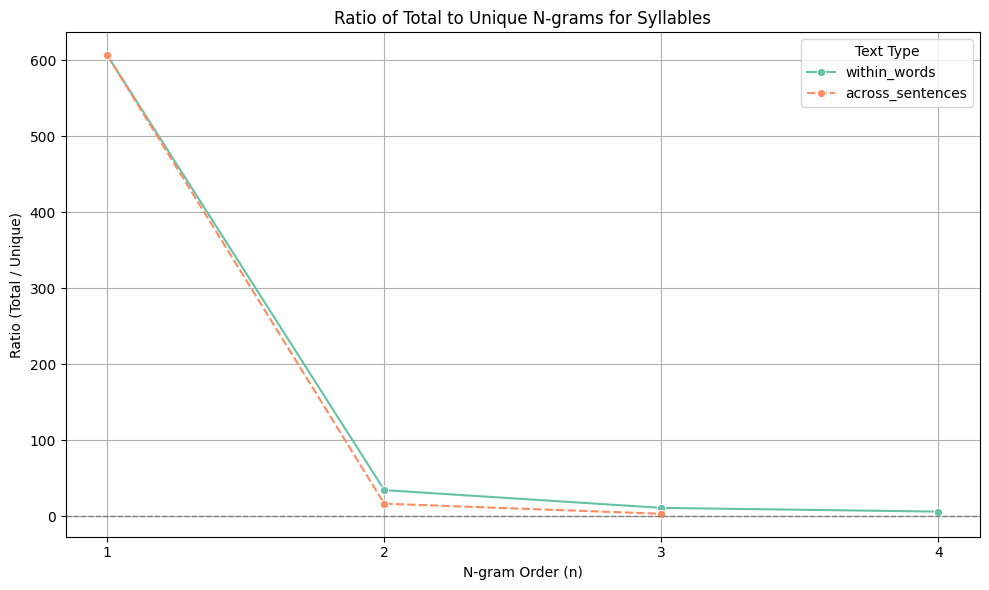

In [15]:
def plot_ratio_sylls_only():
    df_sy = df[df["processing_type"] == "sylls"].copy()
    df_sy["ratio_total_to_unique"] = df_sy["total_ngrams"] / df_sy["unique_ngrams"]

    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df_sy,
        x="n",
        y="ratio_total_to_unique",
        hue="text_type",
        style="text_type",
        estimator="mean",
        errorbar=None,
        marker="o",
        palette="Set2"
    )

    plt.axhline(1.0, linestyle="--", color="gray", linewidth=1)
    plt.title("Ratio of Total to Unique N-grams for Syllables")
    plt.ylabel("Ratio (Total / Unique)")
    plt.xlabel("N-gram Order (n)")
    plt.xticks([1, 2, 3, 4])
    plt.legend(title="Text Type")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_ratio_sylls_only()

#### Observation on High N-gram Syllable Models

Despite the large size of the language corpora, the ratio of unique prefixes to total n-grams remains high, especially for syllable-based models. This becomes particularly evident at higher n-gram orders (e.g., trigrams), where the number of total n-grams drops while the number of unique prefixes rises. When you move to higher n-gram orders, each prefix becomes longer, which increases the number of possible prefix combinations. However, the dataset is finite, so most of these longer prefixes appear only a few times, sometimes only once.

While rare or unique prefixes might yield low conditional entropy (e.g., when only one next syllable is observed), this certainty is statistically unreliable. 

Additive smoothing helps in slightly mitigating this overconfidence by spreading probability mass across possible outcomes, increasing entropy and better reflecting the model's true uncertainty.

The ngram models capture this uncertainty as higher information density (ID). Since the information rate (IR) is defined as `IR = ID × SR`, this also explains the observed rise in IR at n=3 for syllable-based models.

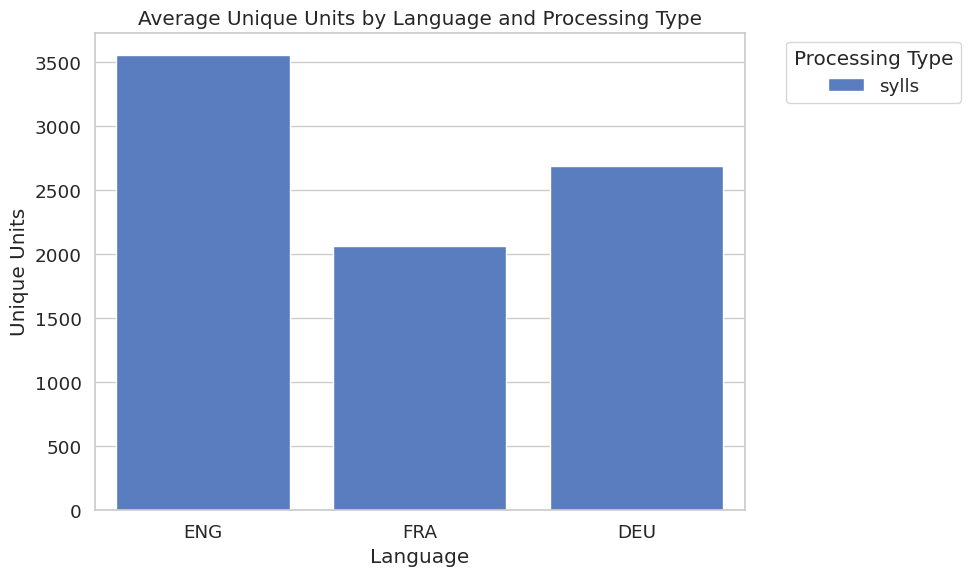

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# Plot styling
sns.set_theme(style="whitegrid", font_scale=1.2)
palette = sns.color_palette("Set2")


# Plot: Unique units by Language and Processing Type

variable = "unique_units" # Change to "total_ngrams" or "unique_prefixes" as needed
var_display = variable.replace("_", " ").title()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x="language",
    y=variable,
    hue="processing_type",  # Differentiates by unit type, e.g., syllables vs phonemes
    estimator=np.mean,
    ci=None,
    palette="pastel"
)
plt.title(f"Average {var_display} by Language and Processing Type")
plt.ylabel(var_display)
plt.xlabel("Language")
plt.legend(title="Processing Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

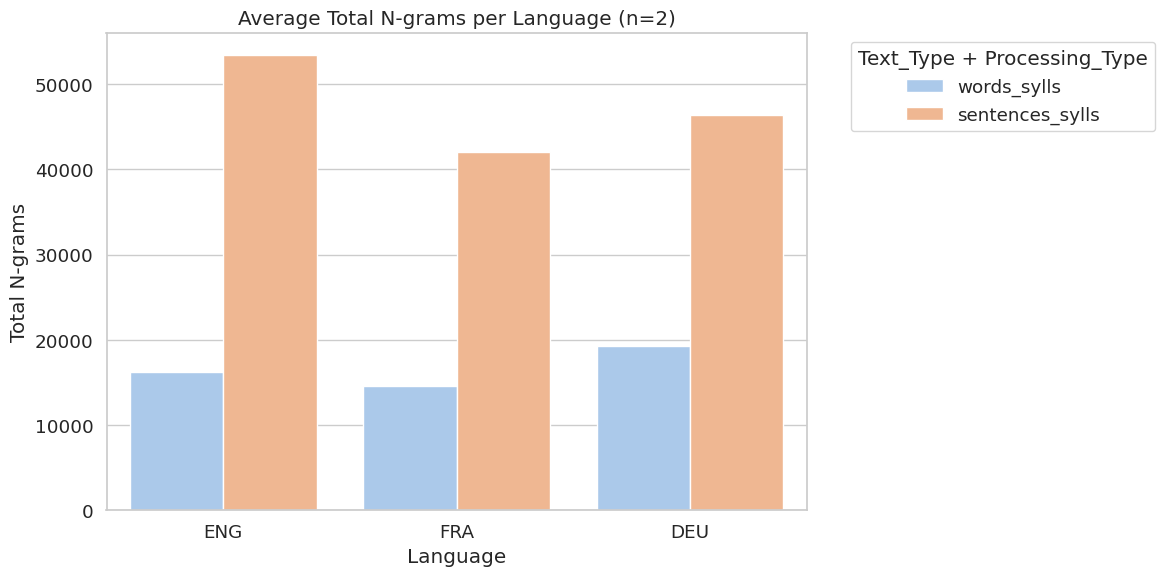

In [ ]:
# Total N-grams by Text Type and Processing Type, per Language
# Filter for a specific n-gram order
n_target = 2  # change this to the desired n
df_n = df[df["n"] == n_target].copy()

# Create combo key, change key if needed
combo_keys = ["text_type", "processing_type"]
df_n["type_combo"] = df_n[combo_keys].astype(str).agg("_".join, axis=1)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_n,
    x="language",
    y="total_ngrams",
    hue="type_combo",
    estimator=np.mean,
    ci=None,
    palette="pastel"
)

plt.title(f"Average Total N-grams per Language (n={n_target})")
plt.ylabel("Total N-grams")
plt.xlabel("Language")
plt.legend(title=" + ".join(combo_keys).replace('_', ' ').title(), bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()